In [2]:
import os
BASE_DIR = os.getcwd()
print(BASE_DIR)

/home/liao/code/aimarcs-SAM/SAM/pkdia/manage


total number of slices is 50


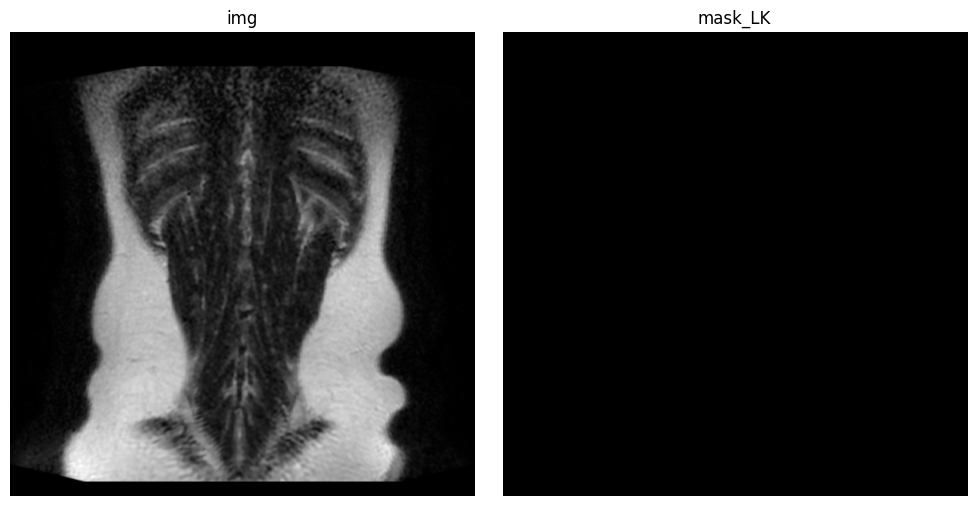

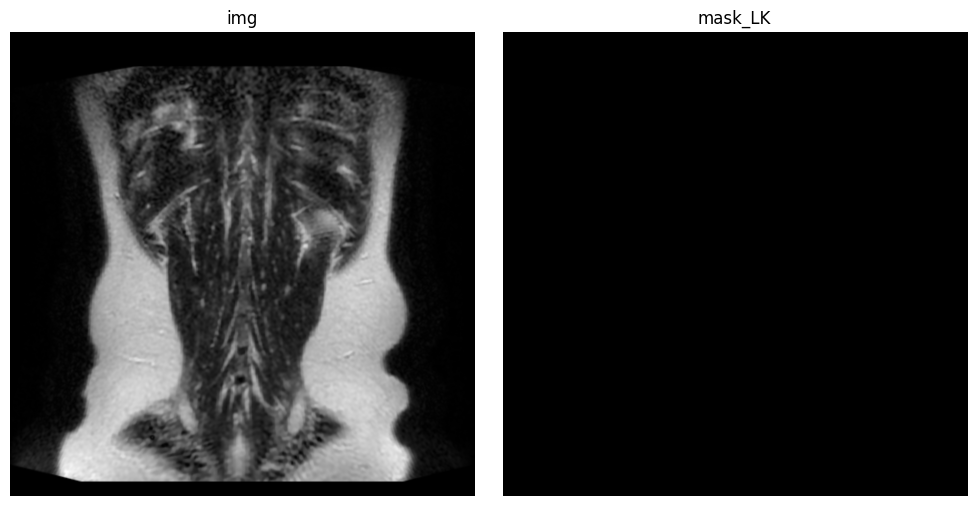

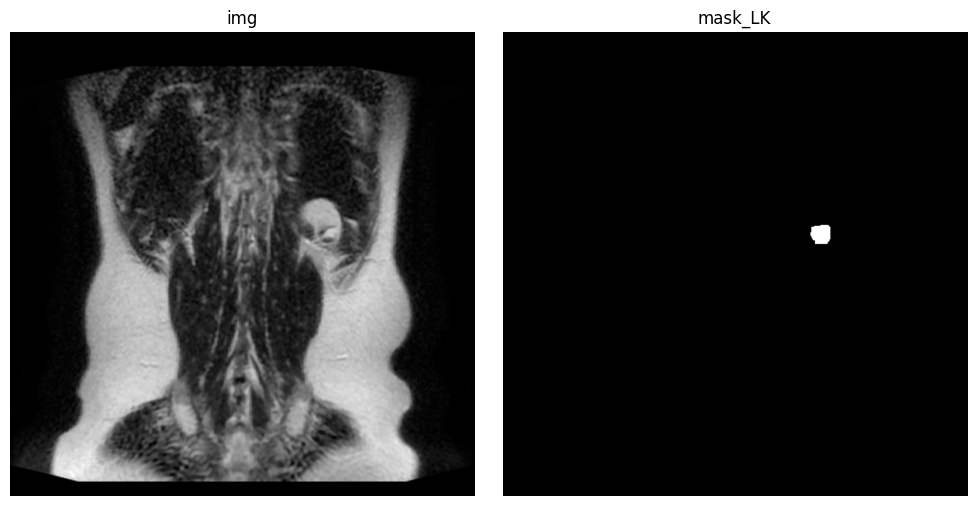

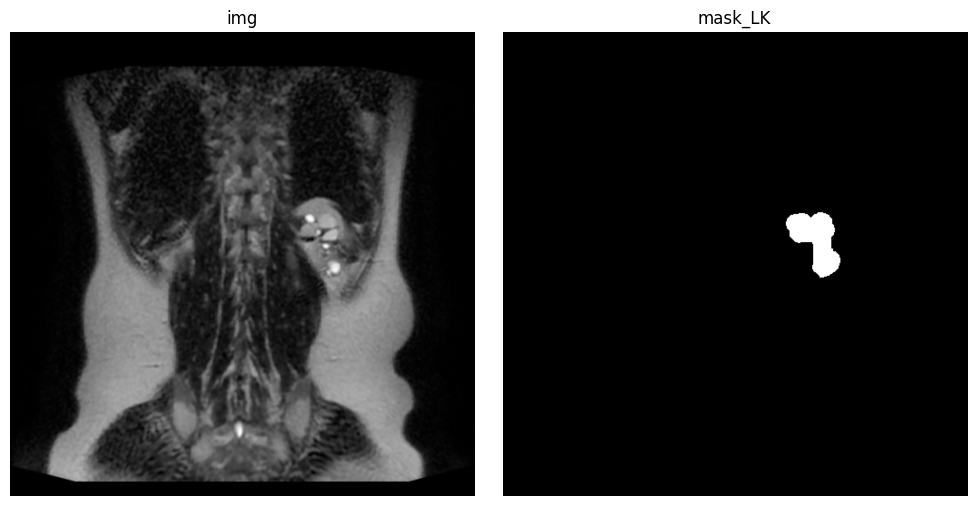

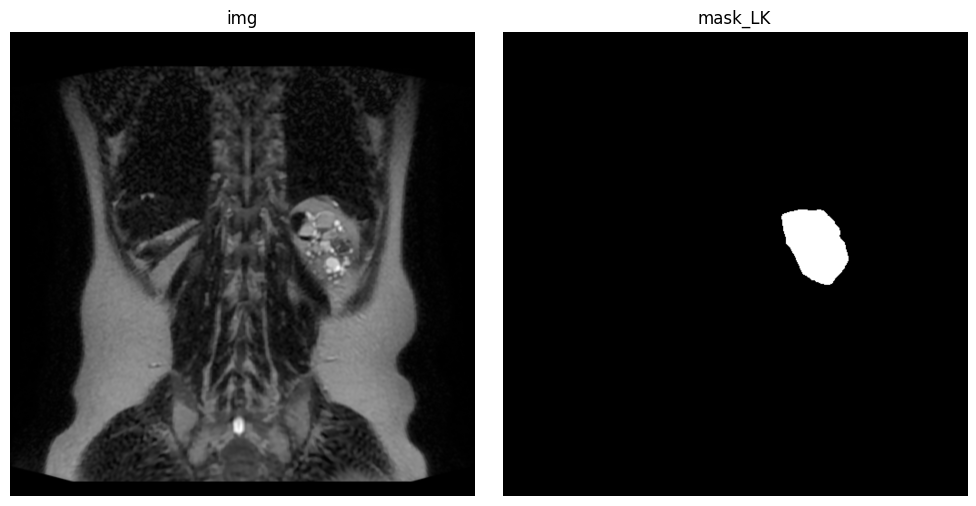

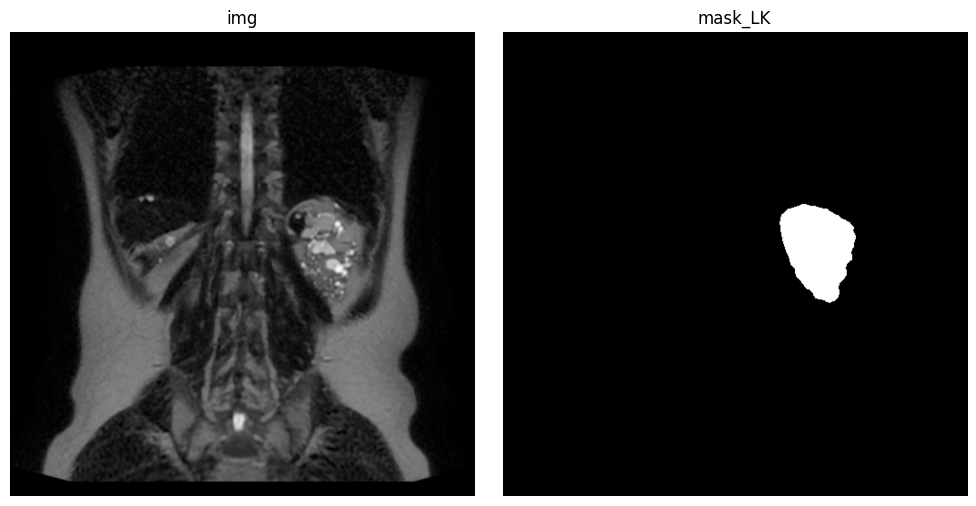

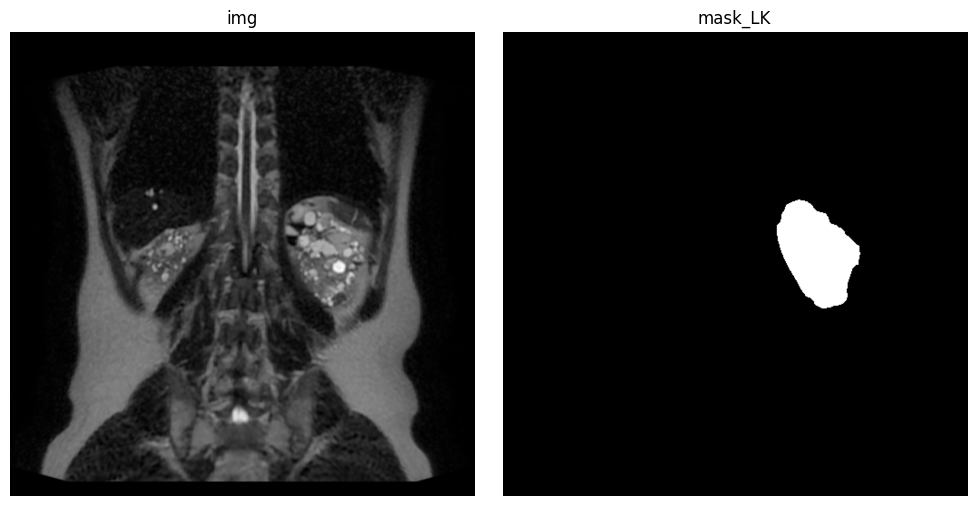

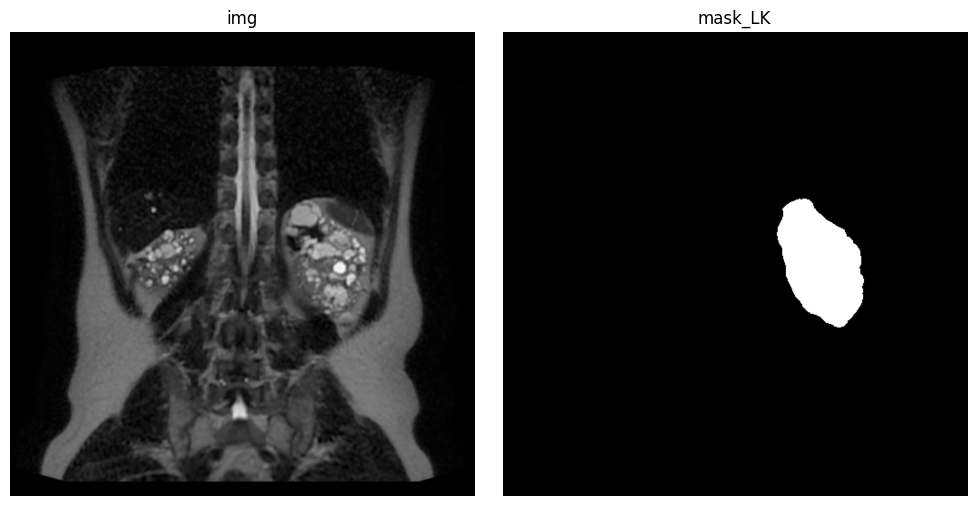

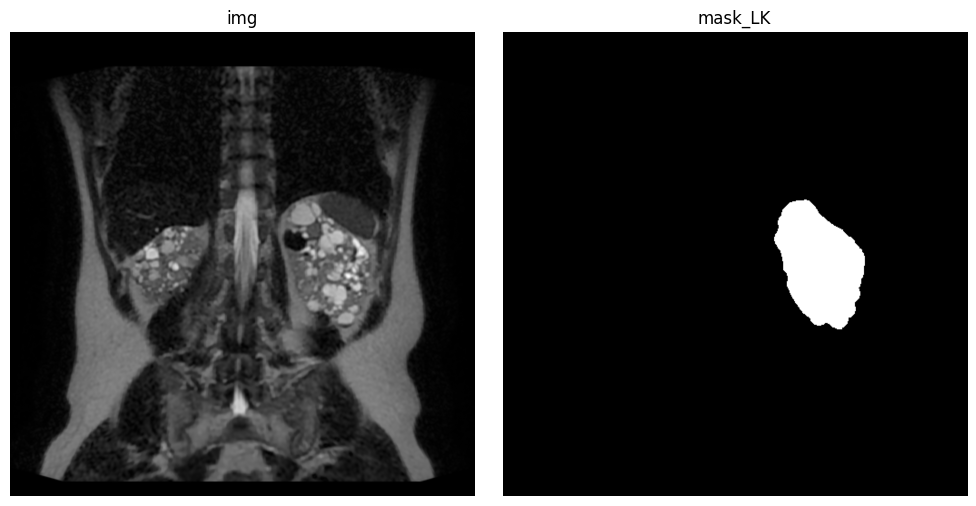

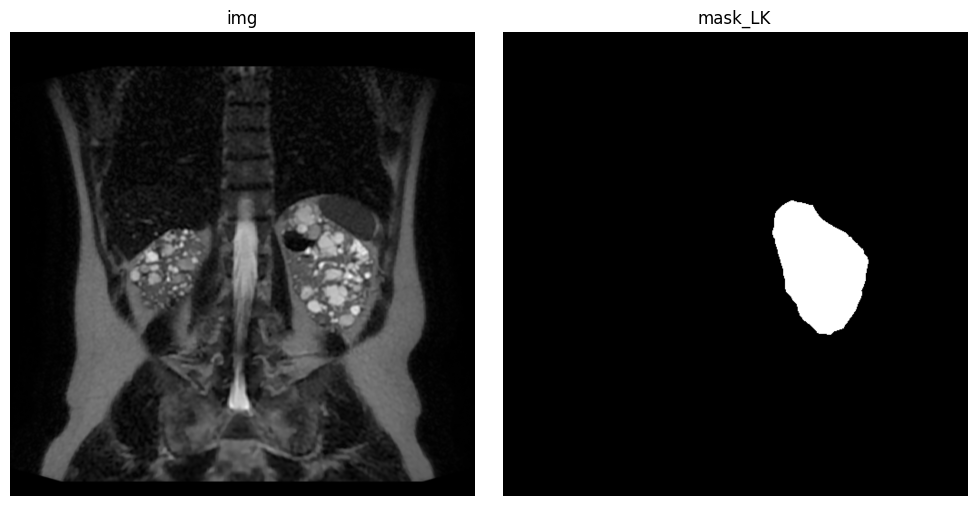

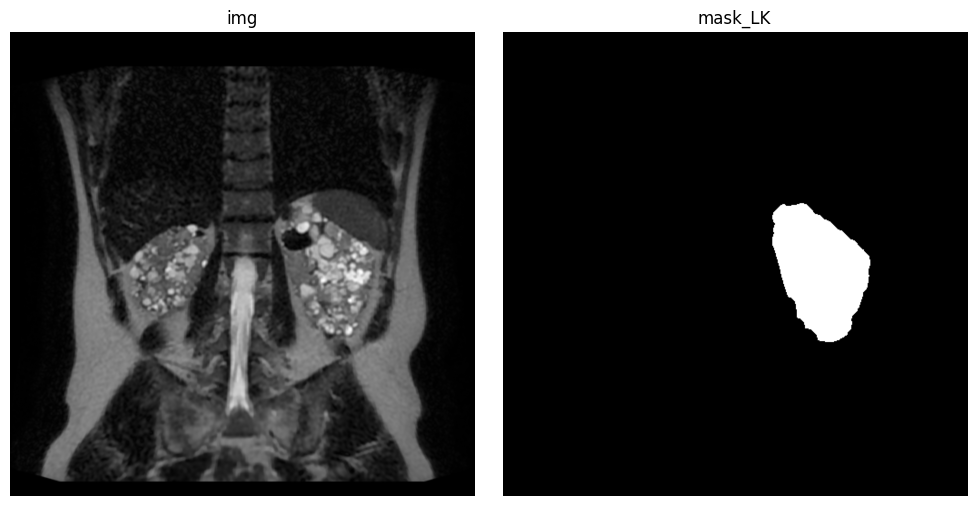

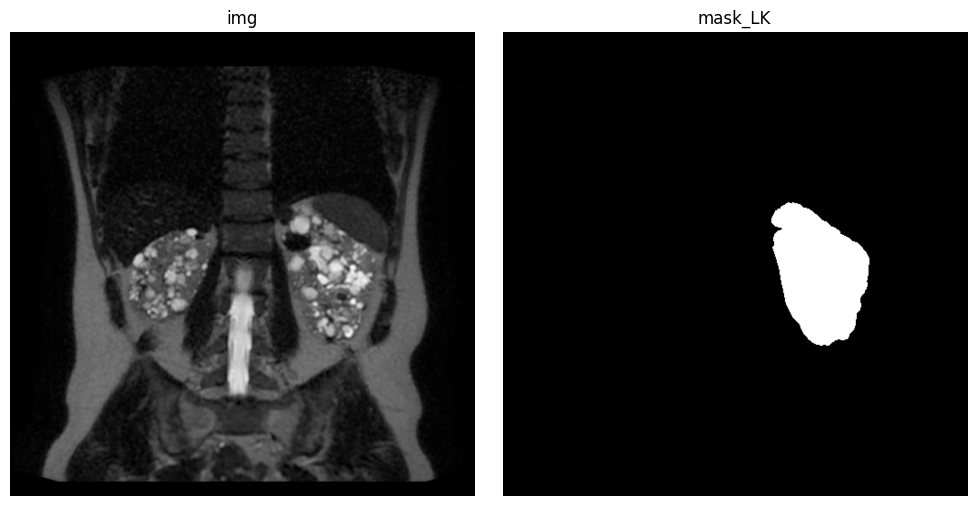

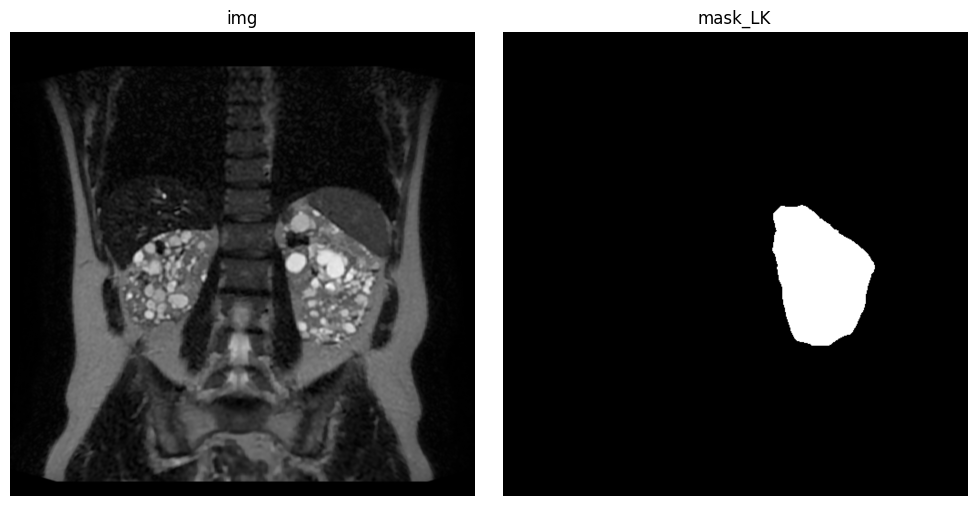

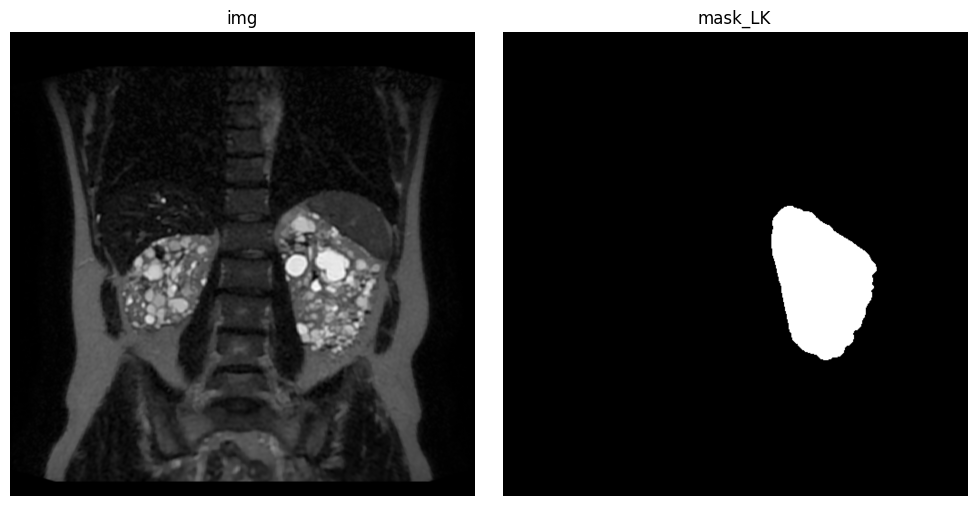

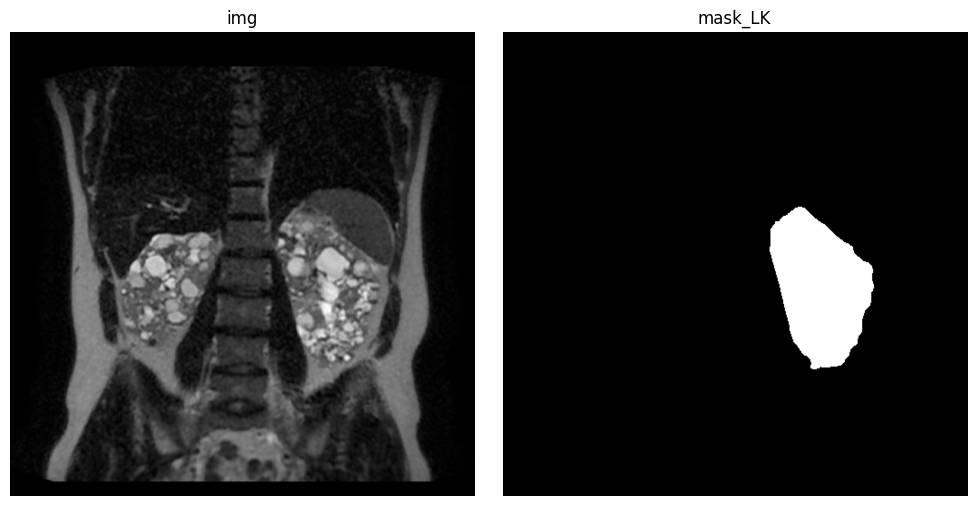

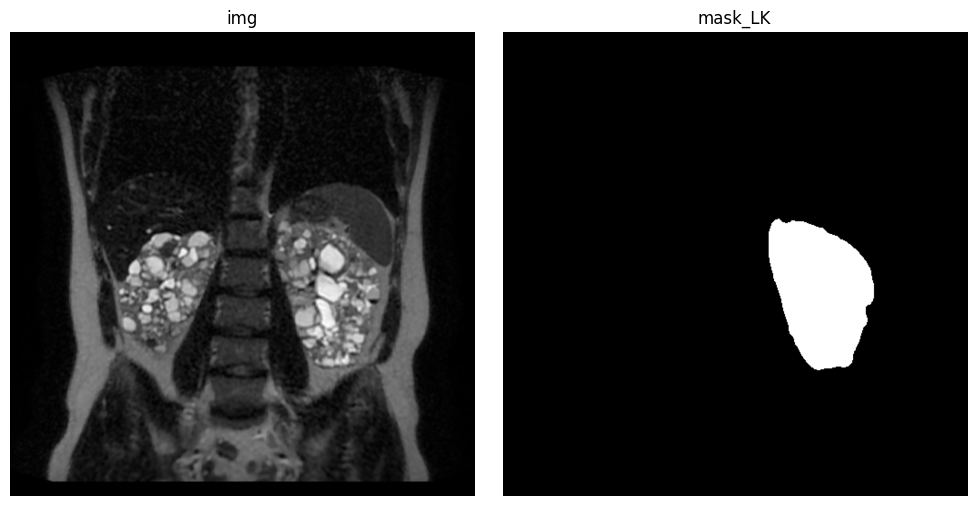

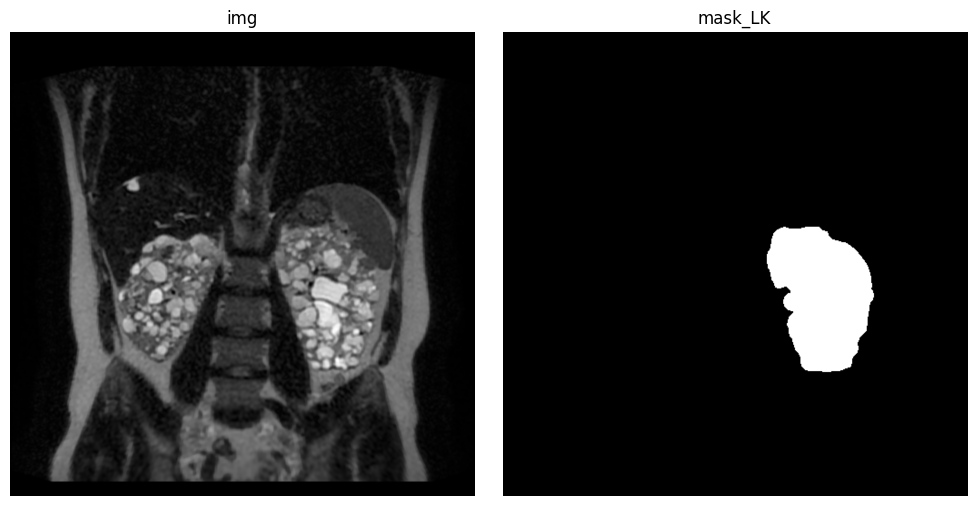

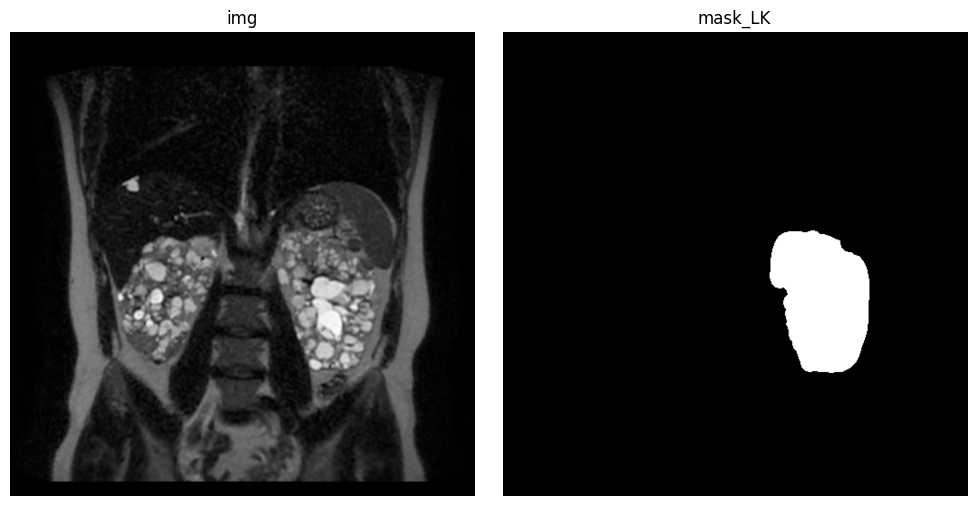

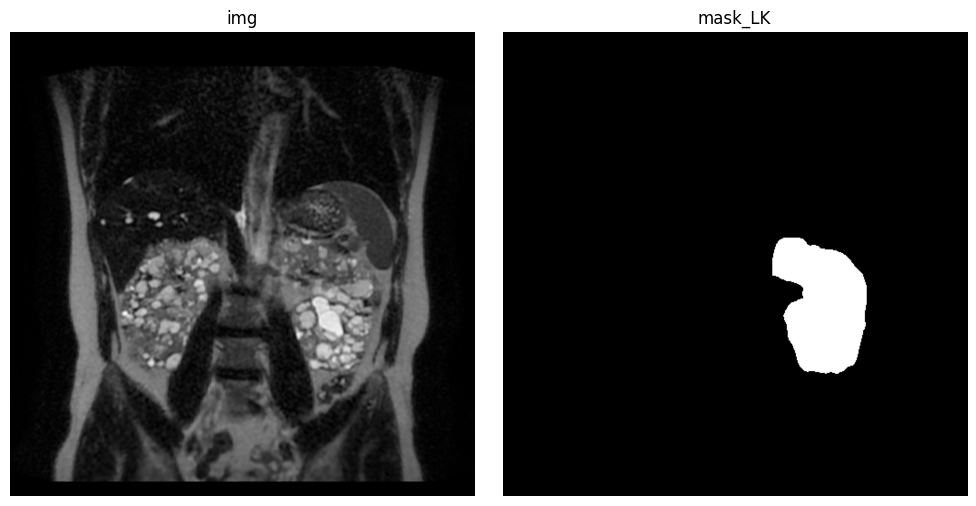

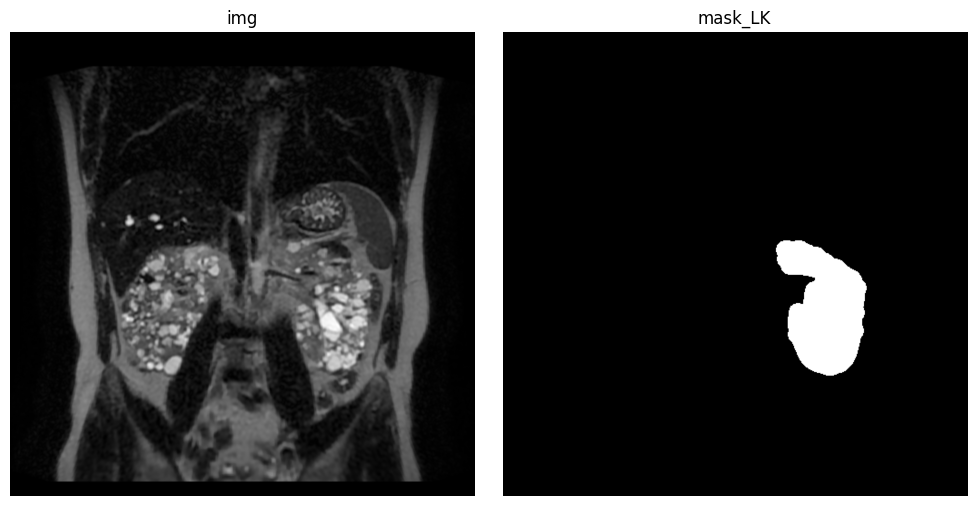

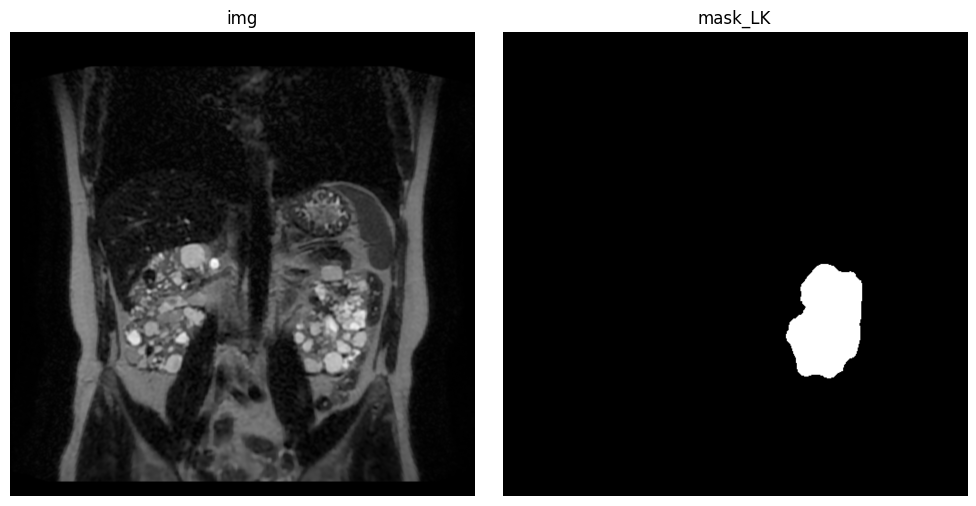

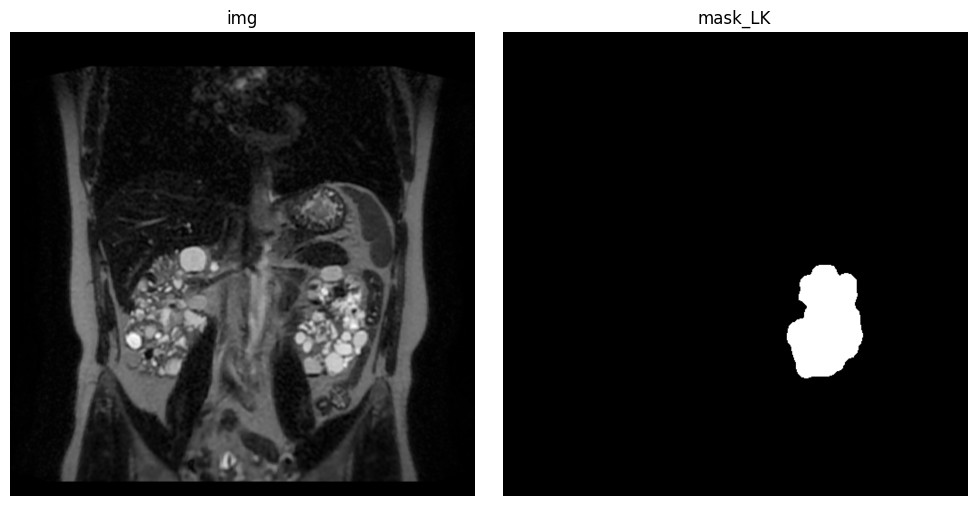

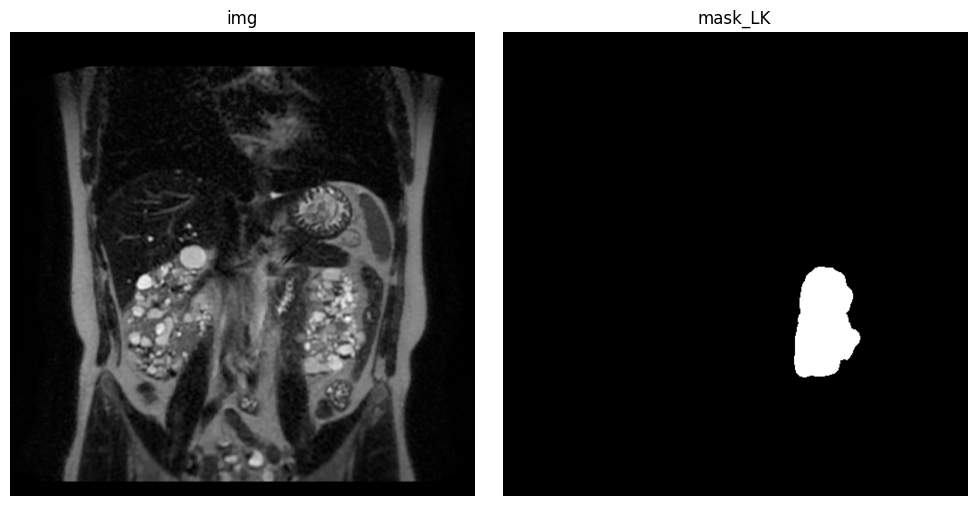

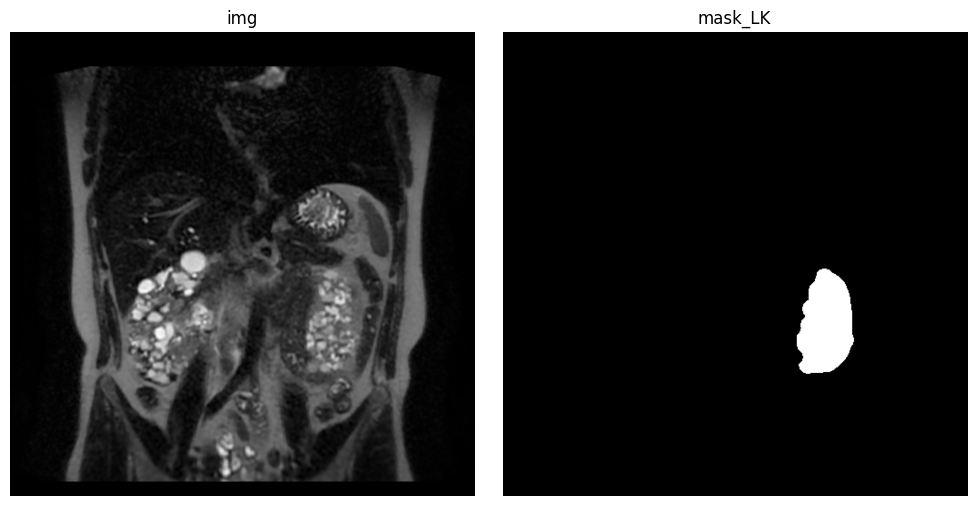

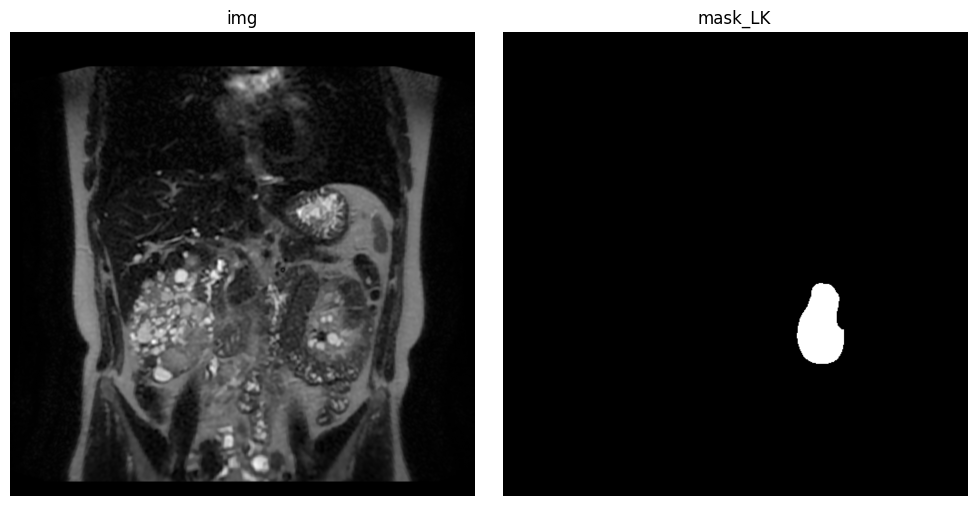

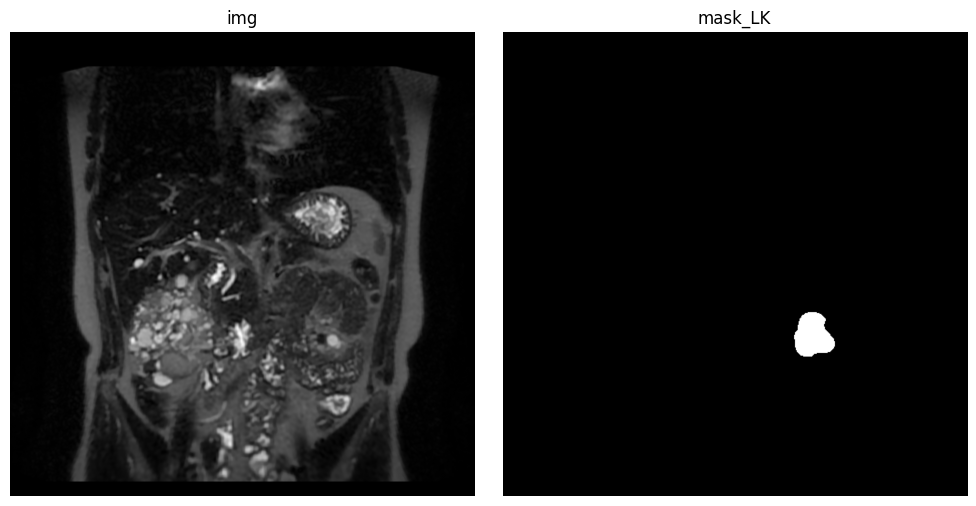

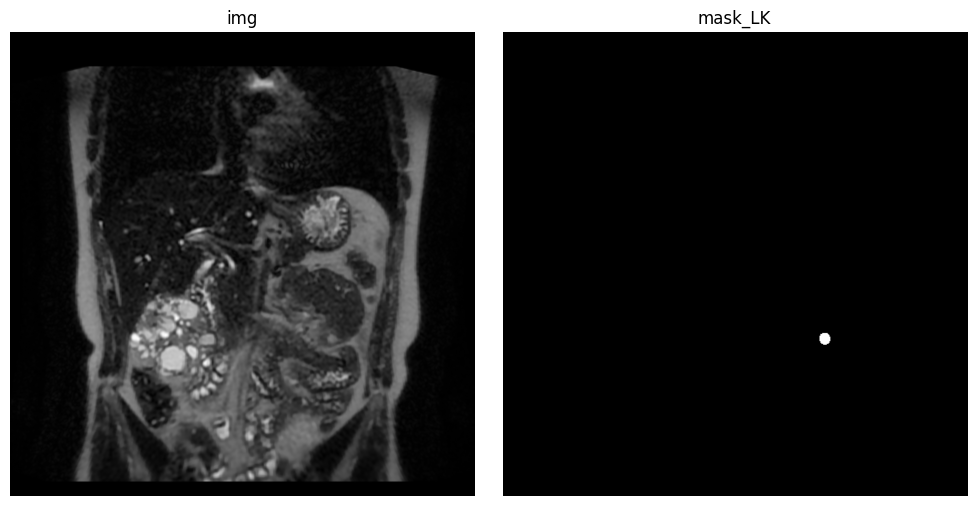

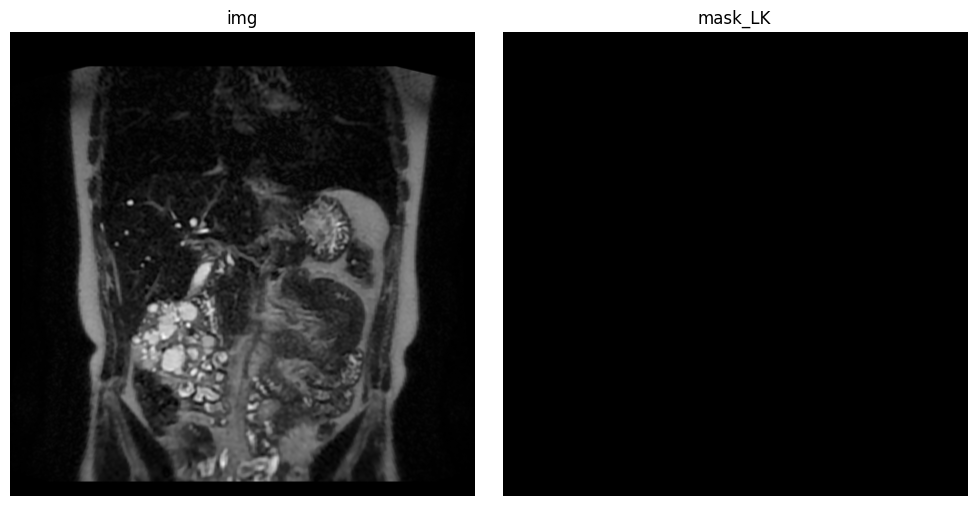

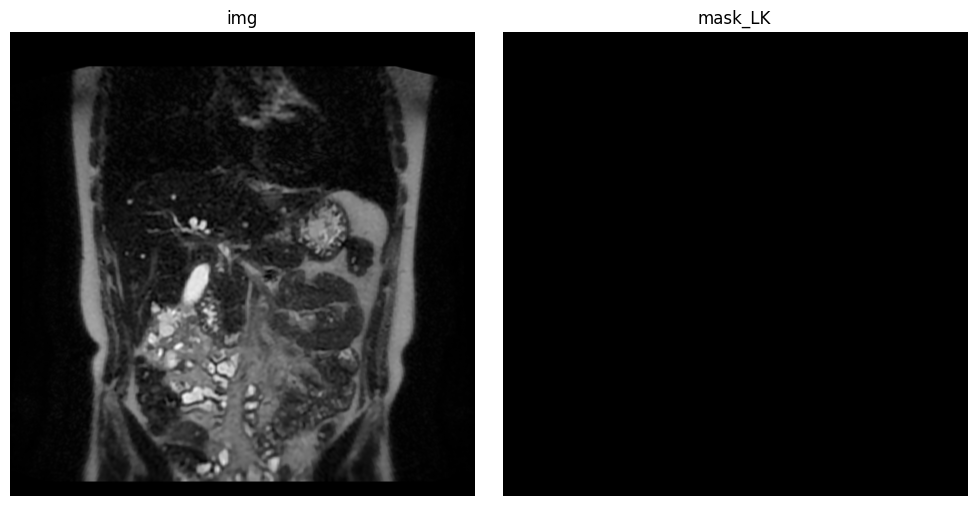

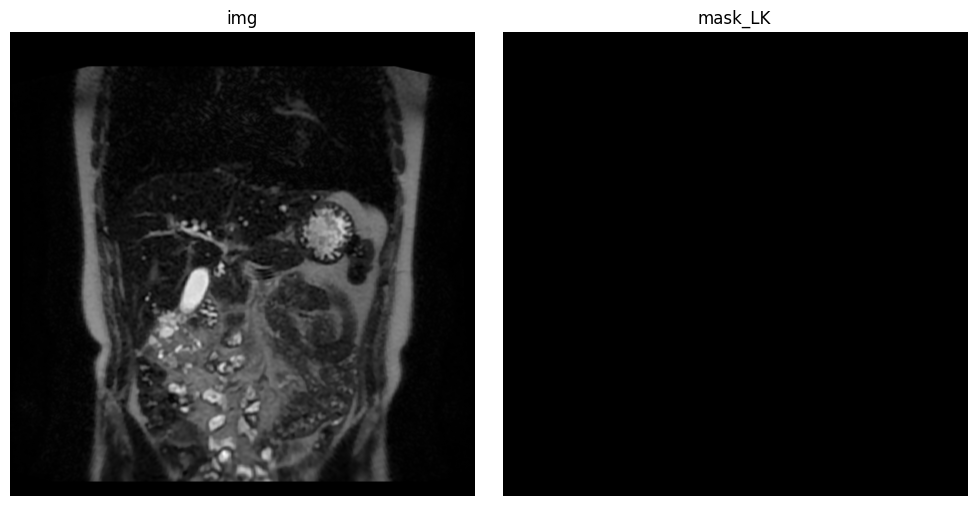

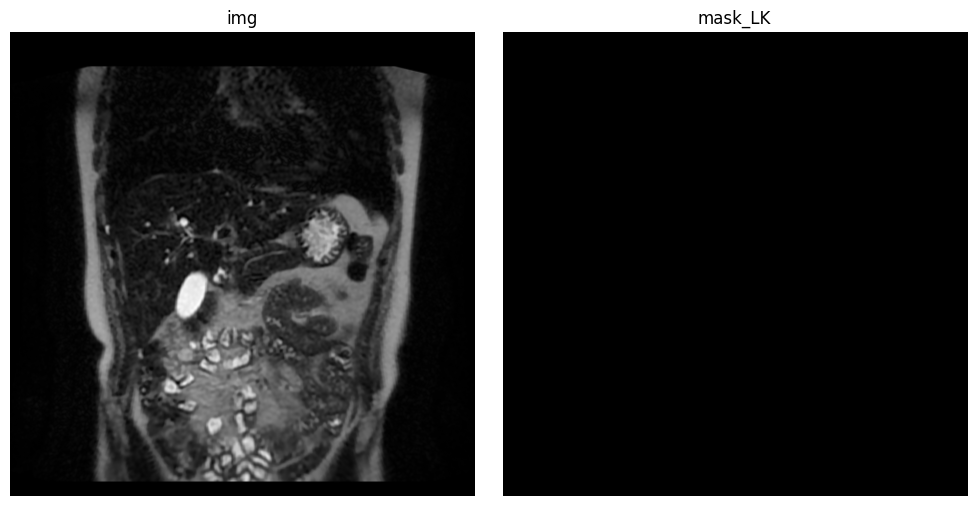

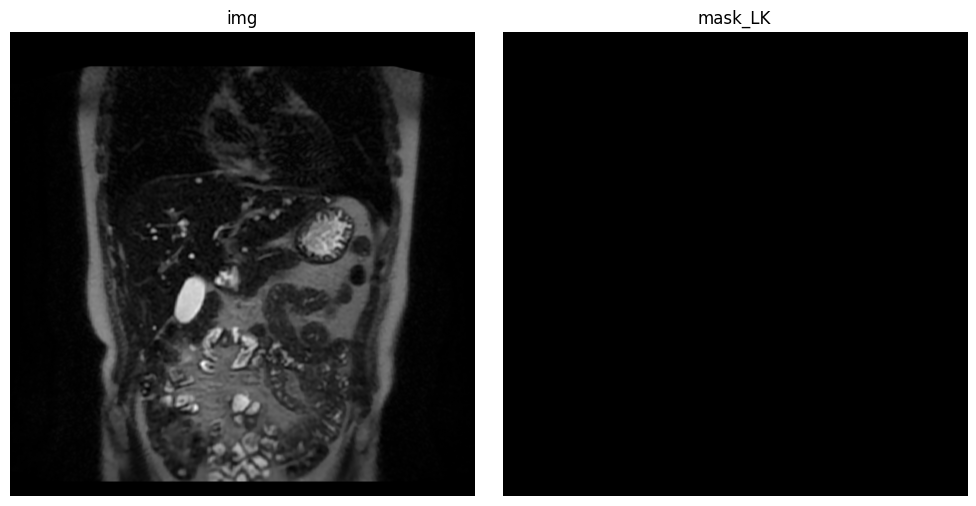

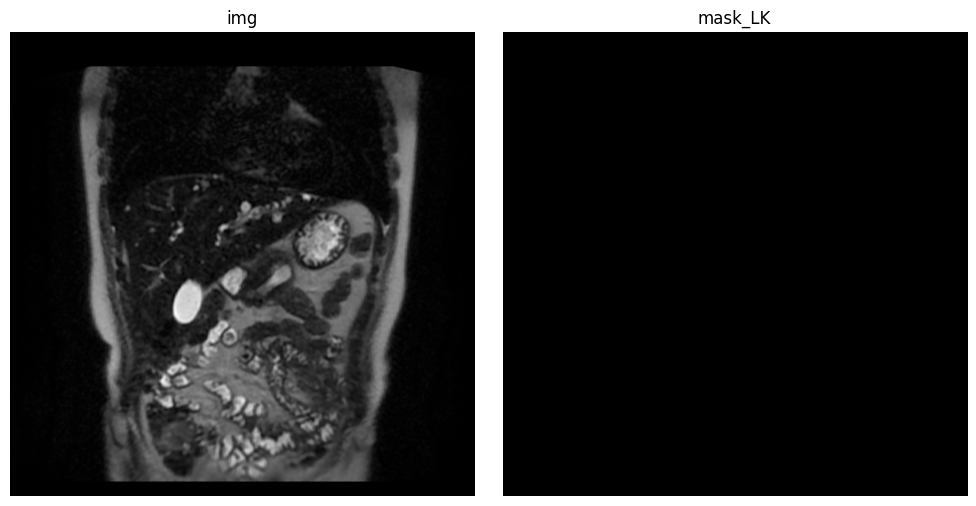

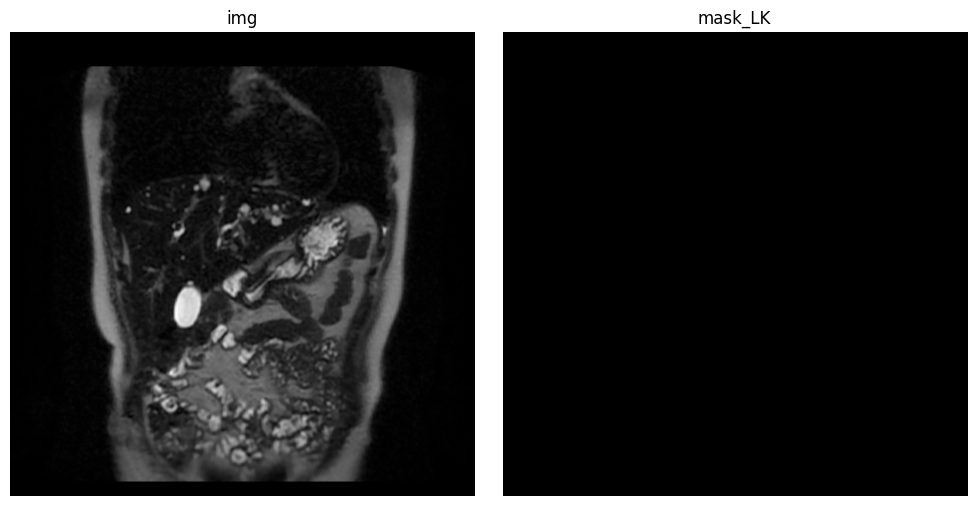

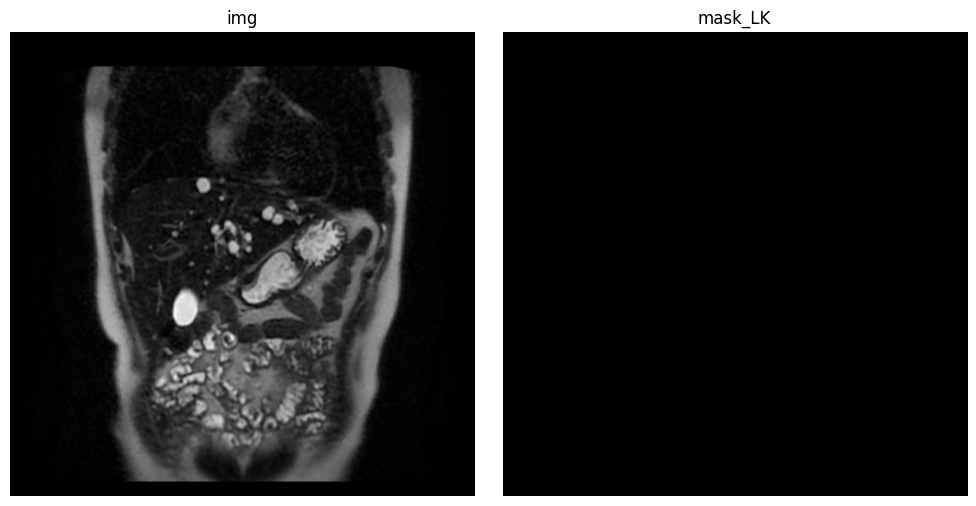

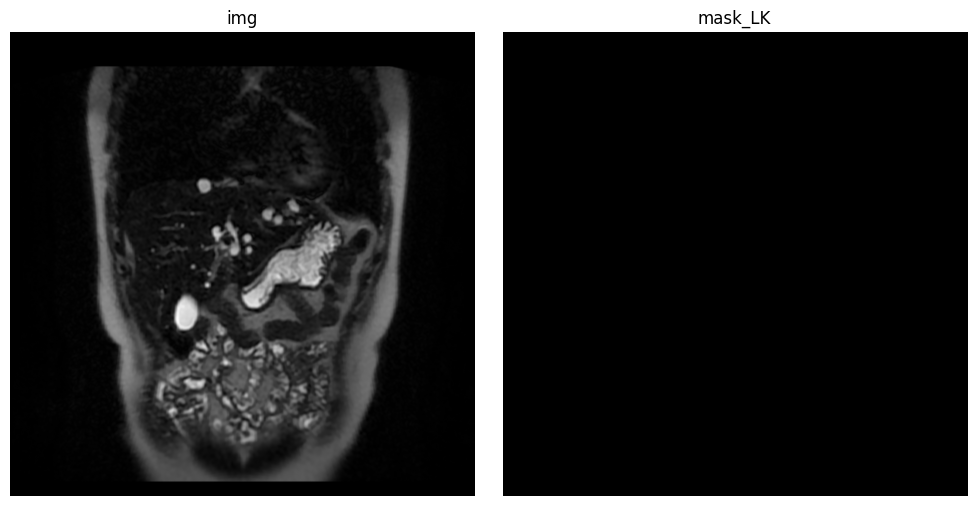

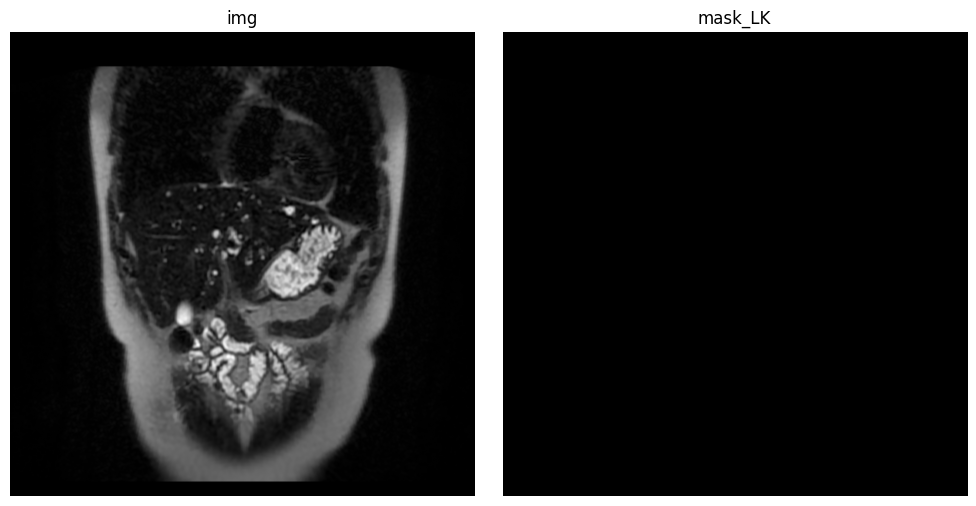

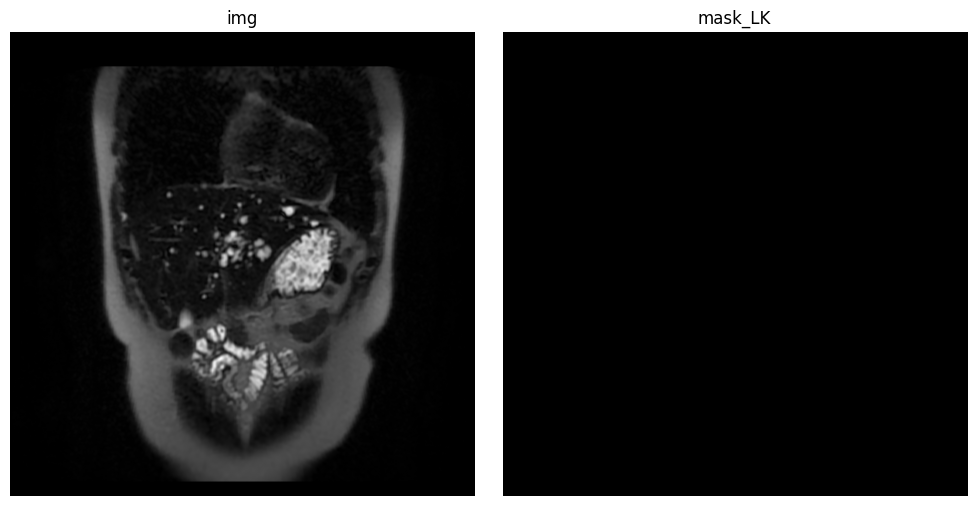

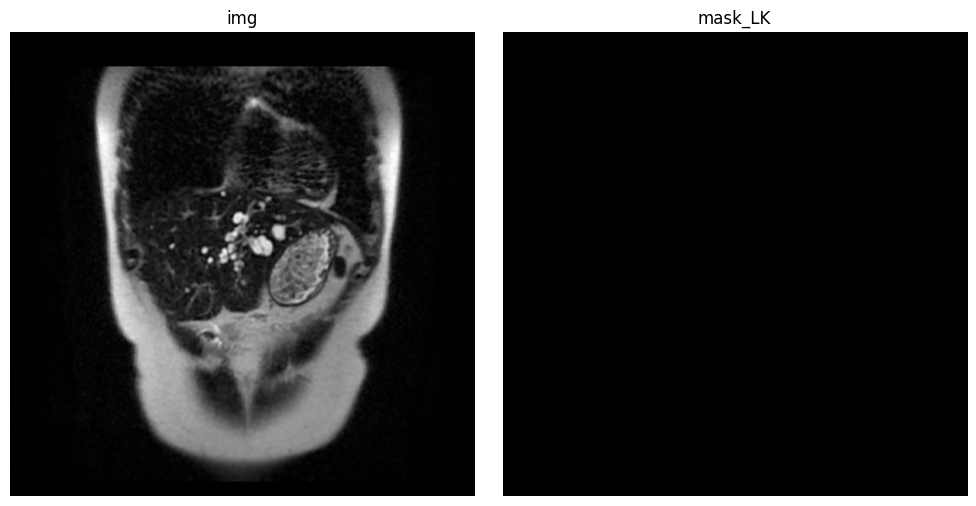

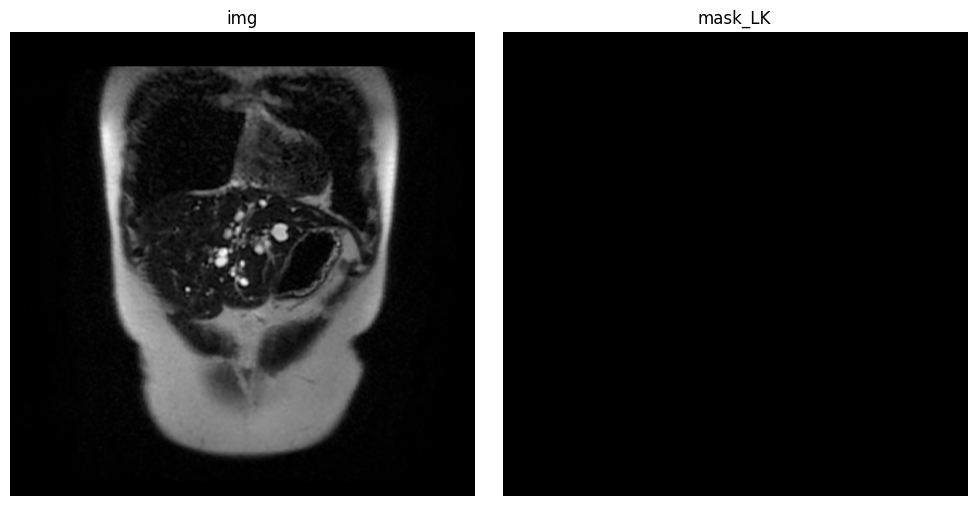

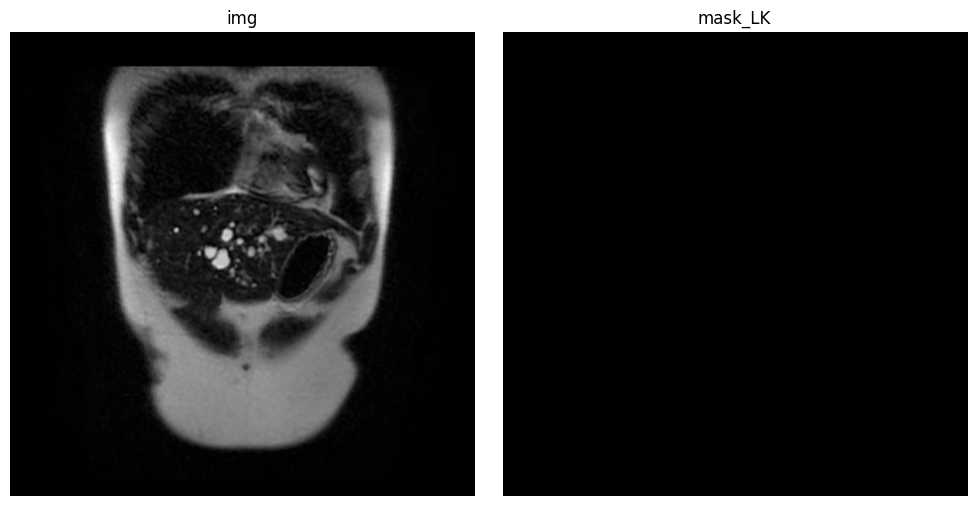

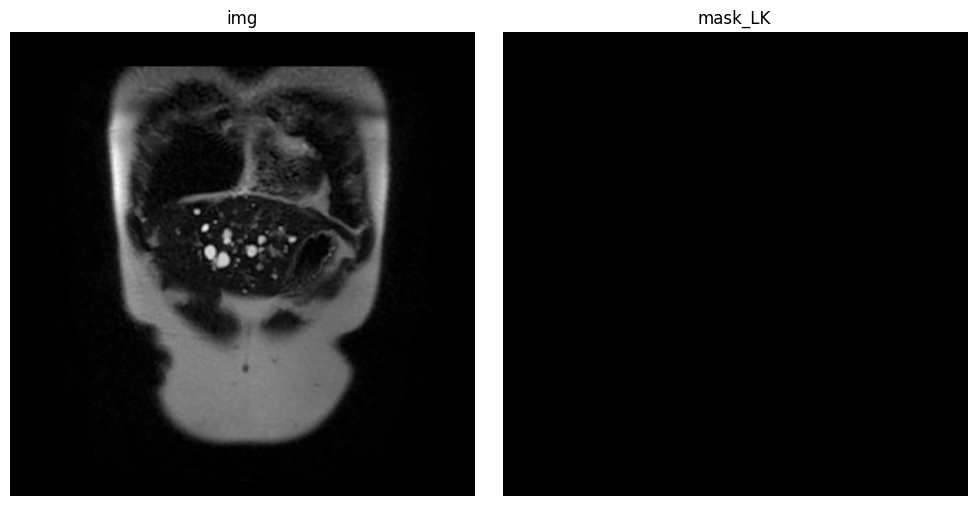

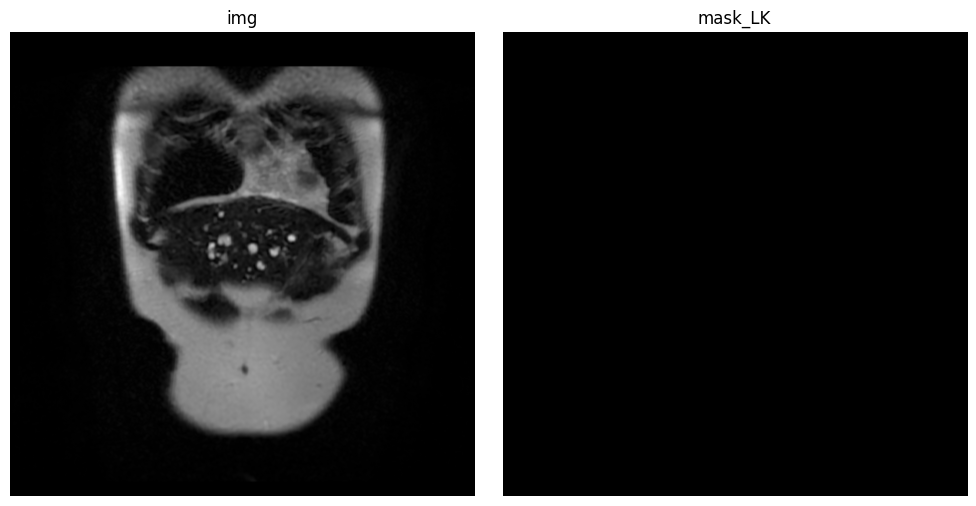

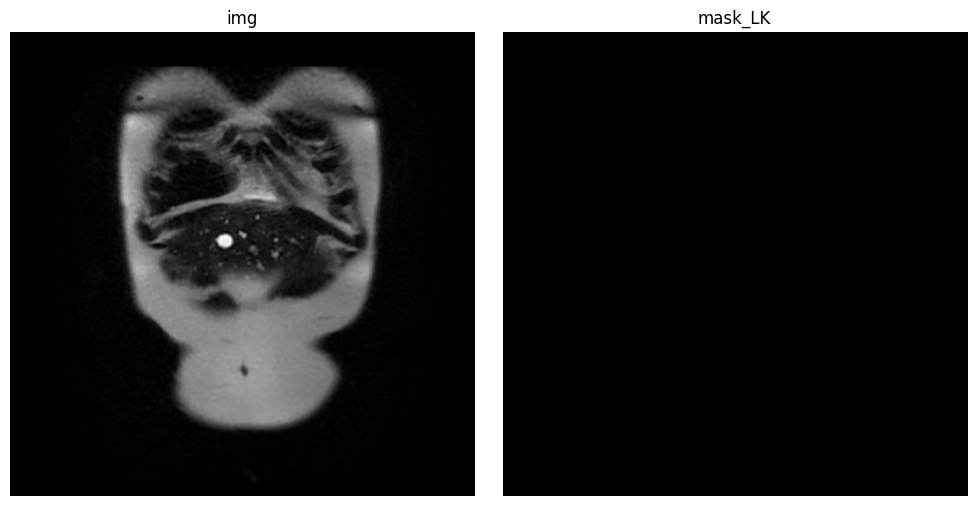

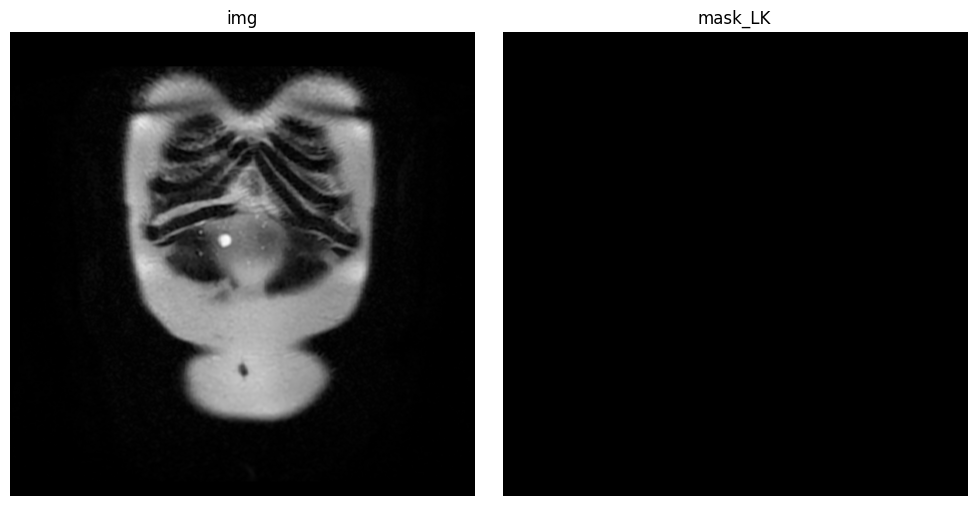

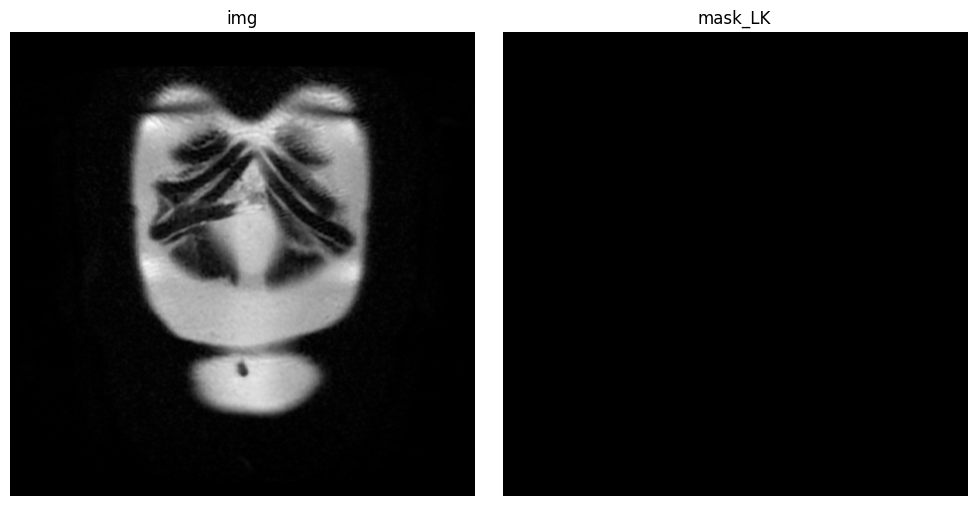

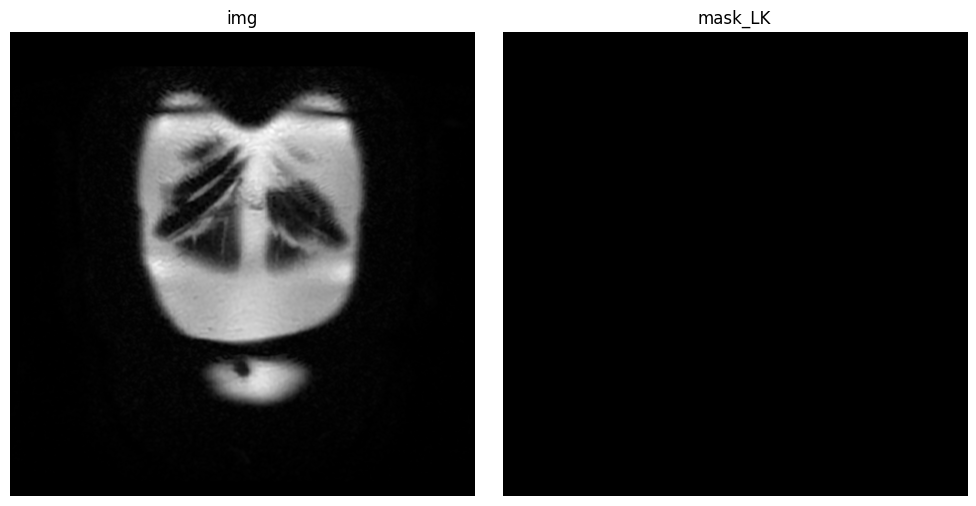

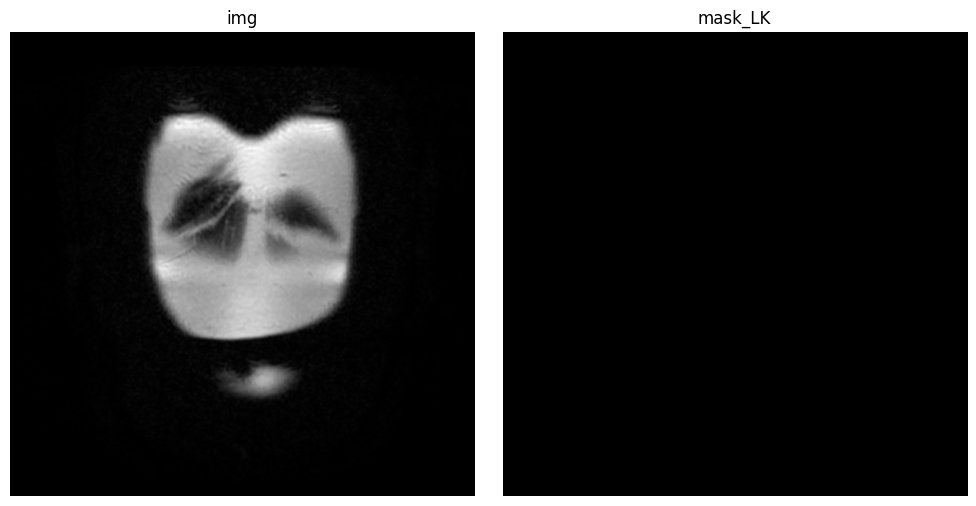

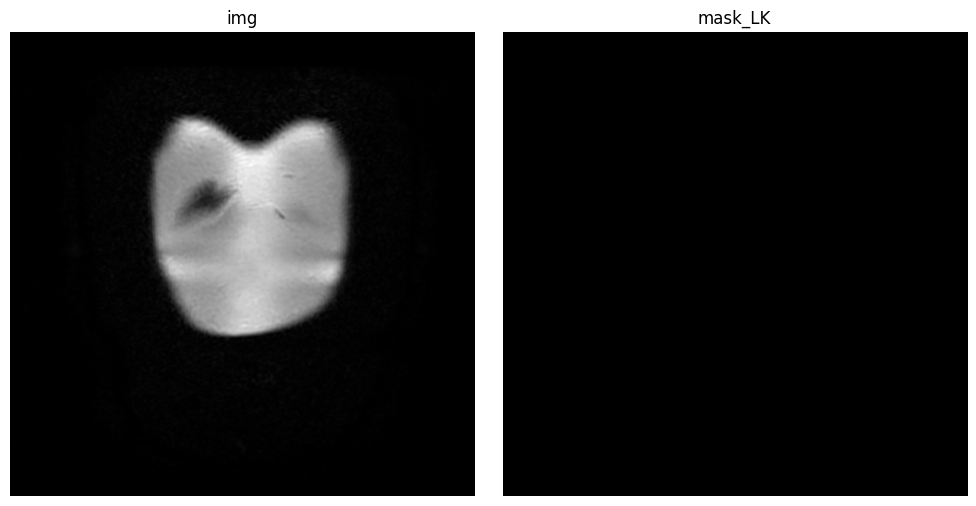

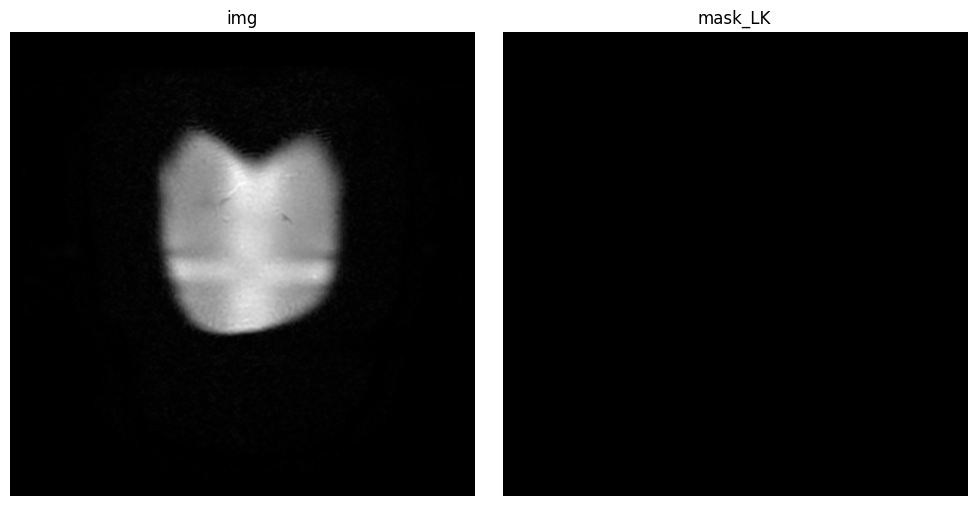

KeyboardInterrupt: 

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-



import numpy as np

from skimage import img_as_ubyte
from skimage.exposure import rescale_intensity
from skimage.transform import resize, rotate
from skimage import io, img_as_ubyte


import os
import nibabel as nib
import matplotlib.pyplot as plt
import cv2
import json
# generating raw slices
def crop_kidney(img, mask):
    # 查找 mask 中的所有轮廓（只取外部轮廓）
    contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        # 如果未找到任何轮廓，直接返回原图
        return img, mask,{}

    all_contours = np.vstack(contours)
    # 计算所有轮廓的最小外接矩形
    x, y, w, h = cv2.boundingRect(all_contours)
    bbox = {
        "x":x,
        "y":y,
        "w":w,
        "h":h
            }


    cropped_img = img[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]
    return cropped_img, cropped_mask, bbox



def extract_genkyst_slice_MT(exam, xyz, modality,size,gamma = 0.8):
    if modality == 'T2':
        img = rotate(resize(np.squeeze(exam.T2.get_fdata()[:,xyz,:])[::-1,:], output_shape=(size,size), preserve_range=True), 90, preserve_range=True)
        mask_LK = rotate(resize(exam.LK.get_fdata()[:,xyz,:][::-1,:]*255, output_shape=(size,size), preserve_range=True), 90, preserve_range=True)
        mask_RK = rotate(resize(exam.RK.get_fdata()[:,xyz,:][::-1,:]*255, output_shape=(size,size), preserve_range=True), 90, preserve_range=True)
    img_norm = (img - img.min()) / (img.max()-img.min())

    img_gamma = np.power(img_norm, gamma)
    img_final = img_as_ubyte(img_gamma)

    mask_LK[np.where(mask_LK > 0)]= 255
    mask_RK[np.where(mask_RK > 0)]= 255

    return img_final, mask_LK.astype(np.uint8), mask_RK.astype(np.uint8)

class Exam:
    pass


patient_id = "010087-01"
t2_path = f"/home/liao/data/genkyst/dataset/{patient_id}-T2.nii.gz"
lk_path = f"/home/liao/data/genkyst/dataset/{patient_id}-LK.nii.gz"
rk_path = f"/home/liao/data/genkyst/dataset/{patient_id}-RK.nii.gz"

exam = Exam()
exam.T2 = nib.load(t2_path)
exam.LK = nib.load(lk_path)
exam.RK = nib.load(rk_path)

target_size = 1024

t2_data = exam.T2.get_fdata()
num_slices = t2_data.shape[1]
print(f"total number of slices is {num_slices}")

output_folder_sample = f"/home/liao/code/aimarcs-SAM/SAM/data/samples_sliced/exam_{patient_id}"
os.makedirs(output_folder_sample,exist_ok=True)
output_folder_LK = f"/home/liao/code/aimarcs-SAM/SAM/data/samples_sliced/exam_{patient_id}/LK"
os.makedirs(output_folder_LK,exist_ok=True)
output_folder_RK = f"/home/liao/code/aimarcs-SAM/SAM/data/samples_sliced/exam_{patient_id}/RK"
os.makedirs(output_folder_RK,exist_ok=True)

before_crop_coordinate_dict = {"LK":{},"RK":{}}
for slice_index in range(num_slices):
    img,mask_LK, mask_RK = extract_genkyst_slice_MT(exam,slice_index,'T2',target_size)

    crop_image_LK, crop_mask_LK, coordinate_dict_LK = crop_kidney(img,mask_LK)
    before_crop_coordinate_dict["LK"][f"slice_{slice_index:03d}"] = coordinate_dict_LK
    crop_image_RK, crop_mask_RK, coordinate_dict_RK= crop_kidney(img,mask_RK)
    before_crop_coordinate_dict["RK"][f"slice_{slice_index:03d}"] = coordinate_dict_RK

    binary_mask_LK = (crop_mask_LK == 255).astype(np.uint8)  
    img_LK = cv2.bitwise_and(crop_image_LK, crop_image_LK, mask=binary_mask_LK)
    binary_mask_RK = (crop_mask_RK == 255).astype(np.uint8) 
    img_RK = cv2.bitwise_and(crop_image_RK, crop_image_RK, mask=binary_mask_RK)

    
    # fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    # axs[0].imshow(img_LK, cmap='gray')
    # axs[0].set_title("cropped LK")
    # axs[0].axis("off")
    # axs[1].imshow(img_RK, cmap='gray')
    # axs[1].set_title("cropped RK")
    # axs[1].axis("off")
    # plt.tight_layout()
    # plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img, cmap='gray')
    axs[0].set_title("img")
    axs[0].axis("off")
    axs[1].imshow(mask_LK, cmap='gray')
    axs[1].set_title("mask_LK")
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()

    # io.imsave(os.path.join(output_folder_LK,f"slice_{slice_index:03d}_LK.png"),img_LK)
    # io.imsave(os.path.join(output_folder_RK,f"slice_{slice_index:03d}_RK.png"),img_RK)

coordinate_save_path = os.path.join(output_folder_sample,f"exam_{patient_id}_coordinate(before_resize).json")
with open(coordinate_save_path,"w",encoding = "utf-8") as f:
        json.dump(before_crop_coordinate_dict,f,indent=4)
print(f"Slice coordinate dictionary(after resized) saved at: {coordinate_save_path}")


print("all results saved")
# finish generating raw slices
# generate preprocessed slices
BASE_DIR = os.getcwd()
SAMPLES_SLICED = os.path.join(BASE_DIR, "../data/samples_sliced")
OUTPUT = os.path.join(BASE_DIR, "../data/samples_preprocessed")
# Specify the input and output folders
output_folder = os.path.join(OUTPUT, "interpolated_images_resized")

def resize_and_interpolate_images(input_folder, output_folder, global_max_width, global_max_height, interpolation=cv2.INTER_LINEAR):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    slice_coordinate_info = {}
    # Find the maximum width and height among all images
    max_width, max_height = global_max_width, global_max_height

    # Resize all images to the maximum width and height by adding black pixels
    for filename in os.listdir(input_folder):
        if filename.endswith(".png"):

            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            if np.all(img == 0):
                # os.remove(img_path)
                # print(f"remove {filename}")
                continue
            height, width = img.shape[:2]

            # Calculate padding to center the image
            pad_top = (max_height - height) // 2
            pad_bottom = max_height - height - pad_top
            pad_left = (max_width - width) // 2
            pad_right = max_width - width - pad_left

            canvas = np.zeros((global_max_height, global_max_width), dtype=img.dtype)
            canvas[pad_top:pad_top+height, pad_left:pad_left+width] = img

            # 仅提取原图区域进行放大
            roi = canvas[pad_top:pad_top+height, pad_left:pad_left+width]
            # 插值放大原图 2 倍
            scaled_roi = cv2.resize(roi, (width * 2, height * 2), interpolation=interpolation)

            # 创建最终的输出画布（尺寸不变）
            final_img = np.zeros_like(canvas)
            new_h, new_w = scaled_roi.shape[:2]

            # 计算放大图像在最终画布中居中的起始位置
            start_y = (global_max_height - new_h) // 2
            start_x = (global_max_width - new_w) // 2

            # 如果放大后的图像超出画布，则进行裁剪
            roi_y_start = 0
            roi_x_start = 0
            if start_y < 0:
                roi_y_start = -start_y
                start_y = 0
            if start_x < 0:
                roi_x_start = -start_x
                start_x = 0

            # 确定粘贴区域的终止位置（可能因裁剪而小于放大图尺寸）
            end_y = min(start_y + new_h - roi_y_start, global_max_height)
            end_x = min(start_x + new_w - roi_x_start, global_max_width)


            final_img[start_y:end_y, start_x:end_x] = scaled_roi[roi_y_start:roi_y_start + (end_y - start_y),
                                                                  roi_x_start:roi_x_start + (end_x - start_x)]

            slice_coordinate_info[filename[:-4]] = {
                "start_y" : start_y,
                "start_x" : start_x,
                "end_y" : end_y,
                "end_x" : end_x
            }


            fig, ax = plt.subplots(1, 1, figsize=(5, 5))
            ax.imshow(final_img, cmap='gray')
            ax.set_title(f"interpolated_img_{filename[:-4]}")
            ax.axis("off")
            plt.tight_layout()
            plt.show()


            # Save the interpolated image in the output folder
            output_path = os.path.join(output_folder, filename)
            cv2.imwrite(output_path, final_img)
            print(f"Interpolated and resized image saved at: {output_path}")
    
    dict_save_path = os.path.join(output_folder,"Slice_coor_dict(after_resized).json")
    with open(dict_save_path,"w",encoding = "utf-8") as f:
        json.dump(slice_coordinate_info,f,indent=4)
    print(f"Slice coordinate dictionary(after resized) saved at: {dict_save_path}")

# Step 1: Find the global maximum width and height across ALL images
global_max_width, global_max_height =1024,1024

patient_path = f"/home/liao/code/aimarcs-SAM/SAM/data/samples_sliced/exam_{patient_id}"
patient_output_path = f"/home/liao/code/aimarcs-SAM/SAM/data/samples_preprocessed/interpolated_images_resized/exam_{patient_id}"
os.makedirs(patient_output_path,exist_ok=True)
# if os.path.isdir(patient_path):
#     for subpatient_folder in os.listdir(patient_path):
#         subpatient_path = os.path.join(patient_path, subpatient_folder)
        
#         if os.path.isdir(subpatient_path):
#             for filename in os.listdir(subpatient_path):
#                 if filename.endswith(".png"):
#                     img_path = os.path.join(subpatient_path, filename)
#                     img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
                    
#                     if img is not None:
#                         height, width = img.shape[:2]
#                         global_max_width = max(global_max_width, width)
#                         global_max_height = max(global_max_height, height)

# print(f"Global max width: {global_max_width}, Global max height: {global_max_height}")

# Step 2: Resize and interpolate all images
# for patient_folder in os.listdir(SAMPLES_SLICED):
#     patient_path = os.path.join(SAMPLES_SLICED, patient_folder)
if os.path.isdir(patient_path):
    # Iterate over each subfolder (subpatient folder) in the patient folder
    for subpatient_folder in os.listdir(patient_path):
        subpatient_path = os.path.join(patient_path, subpatient_folder)
        if os.path.isdir(subpatient_path):
            # Define the output path for the subpatient folder
            # subpatient_output_path = os.path.join(output_folder, patient_folder, subpatient_folder)
            subpatient_output_path = os.path.join(patient_output_path, subpatient_folder)
            # Call the function to resize and interpolate images    
            resize_and_interpolate_images(subpatient_path, subpatient_output_path, global_max_width, global_max_height)



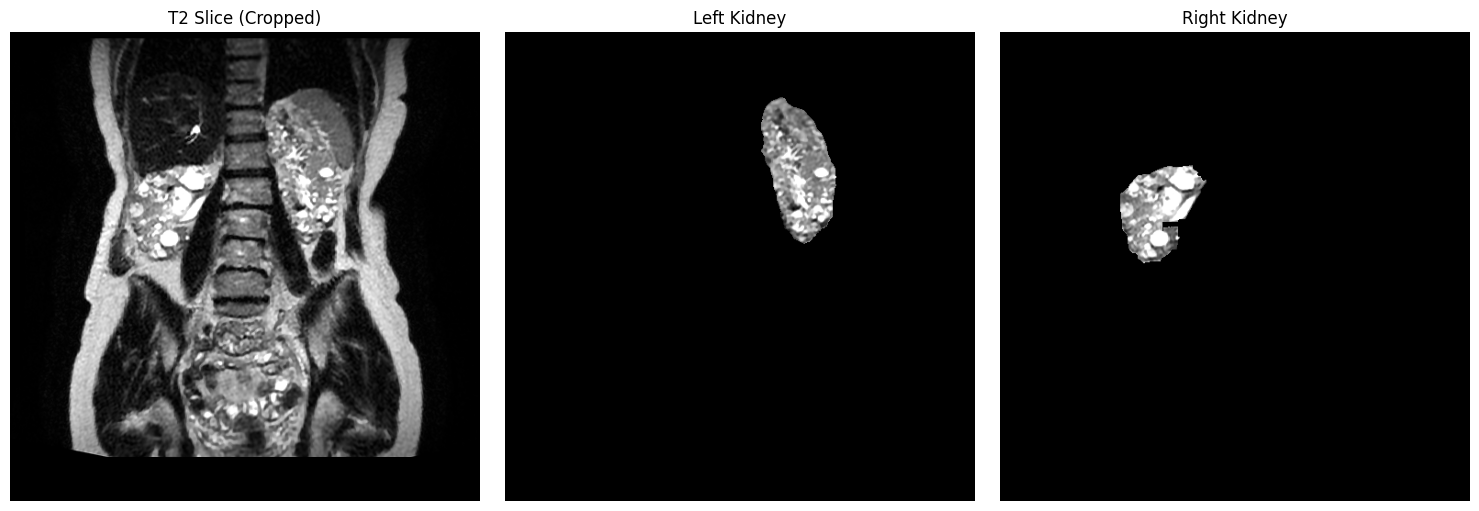

In [14]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize, rotate
from skimage.exposure import rescale_intensity
from skimage import img_as_ubyte, io
import cv2


def extract_genkyst_slice_MT(exam, xyz, modality, size):
    """
    从 exam 对象中提取指定切片，并返回处理后的图像及左右肾的 mask，
    输出图像大小由参数 size 决定（若 size 为一个数，则输出为正方形）。
    
    参数：
      exam: 包含 T2、LK、RK 数据的对象
      xyz: 要提取的切片索引（对于 T2，使用 exam.T2.get_fdata()[:, xyz, :]）
      modality: 'T2' 或 'CT'
      size: 输出图像的尺寸，例如 256 表示输出图像为 256x256（正方形）
      
    返回：
      (img, mask_LK, mask_RK) 均为经过 resize、旋转及对比度调整后的 8 位图像
    """
    if modality == 'T2':
        img = rotate(
                resize(
                    np.squeeze(exam.T2.get_fdata()[:, xyz, :])[::-1, :],
                    output_shape=(size, size),
                    preserve_range=True
                ),
                90,
                preserve_range=True
              )
        mask_LK = rotate(
                     resize(
                         exam.LK.get_fdata()[:, xyz, :][::-1, :]*255,
                         output_shape=(size, size),
                         preserve_range=True
                     ),
                     90,
                     preserve_range=True
                   )
        mask_RK = rotate(
                     resize(
                         exam.RK.get_fdata()[:, xyz, :][::-1, :]*255,
                         output_shape=(size, size),
                         preserve_range=True
                     ),
                     90,
                     preserve_range=True
                   )
    elif modality == 'CT':
        img = rotate(
                resize(
                    np.squeeze(exam.CT.get_fdata()[:, :, xyz])[::-1, :],
                    output_shape=(size, size),
                    preserve_range=True
                ),
                90,
                preserve_range=True
              )
        mask_LK = rotate(
                     resize(
                         exam.LK.get_fdata()[:, :, xyz][::-1, :]*255,
                         output_shape=(size, size),
                         preserve_range=True
                     ),
                     90,
                     preserve_range=True
                   )
        mask_RK = rotate(
                     resize(
                         exam.RK.get_fdata()[:, :, xyz][::-1, :]*255,
                         output_shape=(size, size),
                         preserve_range=True
                     ),
                     90,
                     preserve_range=True
                   )
    # 对图像进行对比度调整
    min_greyscale, max_greyscale = np.percentile(img, (1, 99))
    img = rescale_intensity(img, in_range=(min_greyscale, max_greyscale), out_range=(0, 1))
    
    # 将 mask 中非零部分归一化为 255（即二值化处理）
    mask_LK[np.where(mask_LK > 0)] = 255
    mask_RK[np.where(mask_RK > 0)] = 255

    # 转换为 8 位图像
    img = img_as_ubyte(img)
    mask_LK = mask_LK.astype(np.uint8)
    mask_RK = mask_RK.astype(np.uint8)
    
    # 裁剪：让输出图像刚好包含左右肾 mask 的联合区域
    
    return img, mask_LK, mask_RK

# 示例：构造 exam 对象，并调用 extract_genkyst_slice_MT
class Exam:
    pass

# 假设你有如下 NIfTI 文件路径
patience_id = "010005-01"
t2_path = f"/home/liao/data/genkyst/dataset/{patience_id}-T2.nii.gz"
lk_path = f"/home/liao/data/genkyst/dataset/{patience_id}-LK.nii.gz"
rk_path = f"/home/liao/data/genkyst/dataset/{patience_id}-RK.nii.gz"

exam = Exam()
exam.T2 = nib.load(t2_path)
exam.LK = nib.load(lk_path)
exam.RK = nib.load(rk_path)

# 指定你要提取的切片索引和输出尺寸（例如输出为正方形 256x256）
slice_index = 20
output_size = 512


img, mask_LK, mask_RK = extract_genkyst_slice_MT(exam, slice_index, 'T2', output_size)

binary_mask_LK = (mask_LK == 255).astype(np.uint8)  # 保证 mask 为 0 或 1 后乘以 255（这里也可以直接用 mask_LK，如果已经是二值化的 0/255）
img_LK = cv2.bitwise_and(img, img, mask=binary_mask_LK)
binary_mask_RK = (mask_RK == 255).astype(np.uint8)  # 保证 mask 为 0 或 1 后乘以 255（这里也可以直接用 mask_LK，如果已经是二值化的 0/255）
img_RK = cv2.bitwise_and(img, img, mask=binary_mask_RK)

# 显示结果
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img, cmap='gray')
axs[0].set_title("T2 Slice (Cropped)")
axs[0].axis("off")
axs[1].imshow(img_LK, cmap='gray')
axs[1].set_title("Left Kidney")
axs[1].axis("off")
axs[2].imshow(img_RK, cmap='gray')
axs[2].set_title("Right Kidney")
axs[2].axis("off")
plt.tight_layout()
plt.show()
